![Helmholtz AI logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Layer-wise Relevance Propagation (LRP) for DistilBERT

This hands-on tutorial explains a DistilBERT **sentiment-classification** prediction with [Captum's LRP](https://captum.ai/api/lrp.html). You will trace the relevance of the predicted class back to the input tokens.

**Model:** `distilbert-base-uncased-finetuned-sst-2-english`  
**Task:** binary sentiment classification (`POSITIVE` / `NEGATIVE`)

## Learning objectives

By the end of this notebook, you will be able to:

1. obtain a sentiment prediction from a pretrained DistilBERT model;
2. prepare embedding inputs for an attribution method when the original inputs are discrete token IDs;
3. compute and inspect token-level LRP relevance scores; and
4. identify the limitations of applying generic LRP rules to Transformer layers.

> **Important:** Captum natively supports LRP rules for common layers such as `Linear` and `Conv2d`. DistilBERT also uses `LayerNorm`, `GELU`, and attention operations, so this notebook uses a simplified fallback rule. Treat the results as a learning example and check the convergence delta before drawing strong conclusions.

## 1. Getting started

### Before you begin

Install the project dependencies from the repository root:

```bash
pip install -r requirements.txt
```

Then run the cells below in order. The first run downloads the pretrained model and tokenizer from Hugging Face, so it requires an internet connection.

### Step 1.1 — Import the libraries

We use PyTorch for the model inputs, Hugging Face Transformers for DistilBERT, Captum for LRP, and Matplotlib for the final visualization.

### Step 1.2 — Select an available accelerator

The next cell uses CUDA when available, otherwise Apple Silicon's MPS backend, and falls back to the CPU. Note the printed device: CPU execution is supported but may be slower.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers.models.distilbert.modeling_distilbert import create_bidirectional_mask
from captum.attr import LRP
from captum.attr._utils.lrp_rules import IdentityRule
from captum.attr._core.lrp import SUPPORTED_LAYERS_WITH_RULES, SUPPORTED_NON_LINEAR_LAYERS

/Users/haider/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = get_device()
print(f"Using device: {device}")

Using device: mps


## 2. Load a pretrained sentiment classifier

### Step 2.1 — Choose the model

[DistilBERT](https://arxiv.org/abs/1910.01108) is a smaller, faster BERT variant trained through knowledge distillation. The checkpoint below was fine-tuned on the SST-2 sentiment dataset.

### Step 2.2 — Load the tokenizer and model

The tokenizer converts text into the token IDs expected by the model. Calling `model.eval()` disables training-only behaviour such as dropout, making predictions and explanations reproducible.

In [3]:
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

print(model.config.id2label)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 37708.13it/s]

{0: 'NEGATIVE', 1: 'POSITIVE'}


## 3. Background: Layer-wise Relevance Propagation

### Step 3.1 — What question does LRP answer?

For one class score, LRP asks: **which input features contributed to this score, and in which direction?** It redistributes the score backward through the network using layer-specific propagation rules. Here, the input features are token embeddings.

### Step 3.2 — Read the relevance scores

- A **positive** token score supports the class logit being explained.
- A **negative** token score opposes that class logit.
- The scores are **target-specific**: explaining `POSITIVE` can yield different relevance from explaining `NEGATIVE` for the same sentence.
- In ideal LRP, total relevance is approximately conserved while it is propagated backward. We will use Captum's convergence delta to assess this approximation.

Unlike perturbation methods, LRP obtains an explanation with a single backward pass. See the [Captum LRP API](https://captum.ai/api/lrp.html) for its supported layers and rule definitions.

## 4. Prepare DistilBERT for Captum LRP

### Step 4.1 — Explain embeddings instead of token IDs

Token IDs are discrete integers, so gradients and relevance cannot be meaningfully propagated *through* the IDs themselves. We therefore pass the model's **word embeddings** to the attribution method and keep positional embeddings fixed in a wrapper module.

### Step 4.2 — Supply propagation rules

Captum LRP requires an `nn.Module` and a rule for each leaf layer. It knows rules for several common layers. For unsupported leaf layers such as `LayerNorm` and `GELU`, we attach `IdentityRule` as a practical fallback.

> This fallback is an approximation, especially around attention. Later, the convergence delta will help reveal whether relevance was well conserved.

In [4]:
def attach_lrp_rules(module: nn.Module) -> None:
    """Assign IdentityRule to leaf layers Captum LRP does not handle by default."""
    supported = set(SUPPORTED_LAYERS_WITH_RULES.keys()) | set(SUPPORTED_NON_LINEAR_LAYERS)
    for layer in module.modules():
        if layer is module or hasattr(layer, "rule"):
            continue
        if type(layer) in supported or len(list(layer.children())) > 0:
            continue
        layer.rule = IdentityRule()

In [5]:
class DistilBertLRPWrapper(nn.Module):
    """DistilBERT classifier that accepts word embeddings as the LRP input."""

    def __init__(
        self,
        classifier: nn.Module,
        attention_mask: torch.Tensor,
        position_embeddings: torch.Tensor,
    ):
        super().__init__()
        self.config = classifier.config
        self.transformer = classifier.distilbert.transformer
        self.pre_classifier = classifier.pre_classifier
        self.classifier = classifier.classifier
        self.dropout = classifier.dropout
        self.layer_norm = classifier.distilbert.embeddings.LayerNorm
        self.emb_dropout = classifier.distilbert.embeddings.dropout
        self.relu = nn.ReLU()
        self.register_buffer("attention_mask", attention_mask)
        self.register_buffer("position_embeddings", position_embeddings)

    def forward(self, word_embeddings: torch.Tensor) -> torch.Tensor:
        hidden = word_embeddings + self.position_embeddings
        hidden = self.emb_dropout(self.layer_norm(hidden))
        attn_mask = create_bidirectional_mask(
            config=self.config,
            inputs_embeds=hidden,
            attention_mask=self.attention_mask,
        )
        hidden = self.transformer(
            hidden_states=hidden,
            attention_mask=attn_mask,
        ).last_hidden_state
        pooled = self.relu(self.pre_classifier(hidden[:, 0]))
        return self.classifier(self.dropout(pooled))

## 5. Make a prediction to explain

### Step 5.1 — Select an input sentence

Start with the positive review below. After completing the tutorial, replace it with a negative or mixed review and compare the explanation.

### Step 5.2 — Inspect the predicted class

The next cell tokenizes the sentence, runs a forward pass, and selects the most likely class. LRP will explain that class's **logit**—the raw score before softmax—not its probability.

In [6]:
text = "This movie was absolutely wonderful and heartwarming."

# TODO: try your own examples
# text = "A dull, predictable story with wooden acting throughout."

In [7]:
encoded = tokenizer(text, return_tensors="pt")
input_ids = encoded["input_ids"].to(device)
attention_mask = encoded["attention_mask"].to(device)

with torch.no_grad():
    logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
    probs = torch.softmax(logits, dim=-1)
    target_idx = logits.argmax(dim=-1).item()

print(f"Text: {text}")
print(f"Prediction: {model.config.id2label[target_idx]}")
print(f"Confidence: {probs[0, target_idx].item():.3f}")

Text: This movie was absolutely wonderful and heartwarming.
Prediction: POSITIVE
Confidence: 1.000


## 6. Compute LRP attributions

### Step 6.1 — Build the attribution input

We extract the word embedding for each token, obtain its matching positional embedding, and create a wrapper with the fixed attention mask and positional embeddings.

### Step 6.2 — Attribute the predicted class logit

`target=target_idx` tells Captum which output to explain. The returned `attributions` tensor has one relevance value for every embedding dimension of every token.

### Step 6.3 — Check the convergence delta

The convergence delta compares the relevance recovered at the input with the selected output score. A value closer to zero indicates better relevance conservation. Because this wrapper uses approximate rules for Transformer components, do not expect perfect conservation.

In [8]:
embeddings = model.distilbert.embeddings
word_embeddings = embeddings.word_embeddings(input_ids)
position_ids = embeddings.position_ids[:, : word_embeddings.size(1)]
position_embeddings = embeddings.position_embeddings(position_ids)

lrp_model = DistilBertLRPWrapper(model, attention_mask, position_embeddings)
attach_lrp_rules(lrp_model)

lrp = LRP(lrp_model)
attributions, convergence_delta = lrp.attribute(
    word_embeddings,
    target=target_idx,
    return_convergence_delta=True,
)

print(f"Convergence delta: {convergence_delta.item():.4e}")
print("(Closer to 0 means better relevance conservation)")

Convergence delta: -2.2301e+21
(Closer to 0 means better relevance conservation)


## 7. Convert embedding relevance into token relevance

### Step 7.1 — Aggregate across embedding dimensions

Each token has a vector of embedding-level relevance values. Sum across that vector to obtain one score per token.

### Step 7.2 — Normalize for comparison

The helper divides by the largest absolute score so the displayed values fall between -1 and 1. This makes tokens easy to compare within this sentence, but it means the scores are not directly comparable between different sentences.

Run the next cell and identify which tokens most strongly support or oppose the predicted class.

In [9]:
def summarize_token_attributions(attributions: torch.Tensor) -> torch.Tensor:
    token_scores = attributions.sum(dim=-1).squeeze(0)
    norm = token_scores.abs().max()
    if norm > 0:
        token_scores = token_scores / norm
    return token_scores


token_scores = summarize_token_attributions(attributions)
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

for token, score in zip(tokens, token_scores.detach().cpu().tolist()):
    print(f"{token:>12}  {score:+.3f}")

       [CLS]  -0.688
        this  -0.055
       movie  +0.050
         was  -0.095
  absolutely  +0.784
   wonderful  -0.046
         and  -0.006
       heart  -0.083
       ##war  +0.051
      ##ming  +0.198
           .  +0.609
       [SEP]  +1.000


## 8. Visualize token relevance

The heatmap makes the token scores easier to scan:

- **Green** tokens support the predicted class.
- **Red** tokens oppose it.
- Darker colours indicate larger normalized relevance magnitudes.

Special tokens such as `[CLS]` and `[SEP]` appear because they are part of the model input. Focus first on meaningful words, then consider whether special-token relevance is substantial.

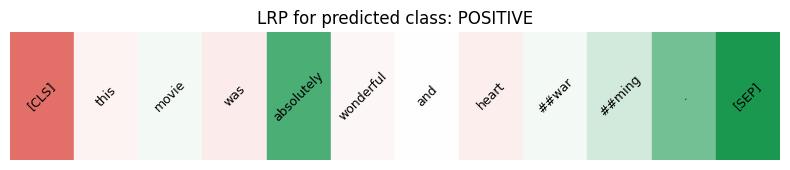

In [10]:
def plot_token_heatmap(tokens, scores, title="LRP token relevance"):
    scores = scores.detach().cpu().numpy()
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "lrp", ["#d73027", "#ffffff", "#1a9850"]
    )
    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    fig, ax = plt.subplots(figsize=(max(8, len(tokens) * 0.6), 1.8))
    for i, (token, score) in enumerate(zip(tokens, scores)):
        color = cmap(norm(score))
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
        ax.text(i + 0.5, 0.5, token, ha="center", va="center", fontsize=9, rotation=45)

    ax.set_xlim(0, len(tokens))
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


plot_token_heatmap(
    tokens,
    token_scores,
    title=f"LRP for predicted class: {model.config.id2label[target_idx]}",
)

## 9. Interpret the explanation

For the default positive review, words such as *wonderful* and *heartwarming* should be plausible candidates for positive relevance. Check the result against the model's confidence and the convergence delta before interpreting it.

### Questions to answer

1. Which three tokens have the largest positive relevance?
2. Do any tokens oppose the predicted class? Does that make sense in context?
3. Is the convergence delta sufficiently close to zero to trust relevance conservation here?

### Exercise

Replace `text` with a negative review, rerun from Section 5, and compare the signs and rankings of sentiment-bearing tokens. Then explain the *other* class by changing `target=target_idx` to the index of the opposite label.

## 10. Next steps

### Exercise 1 — Explain the other class

Set `target` in `lrp.attribute(...)` to the index of the class that was *not* predicted. Compare which tokens support and oppose that alternative decision.

### Exercise 2 — Compare methods

Run the same example with [Integrated Gradients](https://captum.ai/api/integrated_gradients.html) or [Layer Integrated Gradients](https://captum.ai/api/layer.html#layer-integrated-gradients). Do sentiment words receive similar importance rankings? Different methods answer related, but not identical, questions.

### Exercise 3 — Inspect intermediate layers

Explore [LayerLRP](https://captum.ai/api/layer.html#layer-lrp) to inspect relevance at an intermediate representation, such as the `[CLS]` embedding before the classifier.

### Go further: attention-aware LRP

For research-grade transformer relevance propagation, investigate [AttnLRP / LXT](https://github.com/rachtibat/LRP-eXplains-Transformers). It provides rules designed for attention operations, including softmax and query/key/value interactions.

### Limitation to remember

Attention uses softmax and matrix multiplications that require specialised LRP rules. This notebook applies `IdentityRule` to unsupported components, which is a simplification. A large convergence delta is therefore evidence that relevance was not well conserved—not a result to ignore.

## References

- Bach et al., [*On Pixel-Wise Explanations for Non-Linear Classifier Decisions by Layer-Wise Relevance Propagation*](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0130140) (2015)
- [Captum LRP documentation](https://captum.ai/api/lrp.html)
- Sanh et al., [*DistilBERT, a distilled version of BERT*](https://arxiv.org/abs/1910.01108) (2019)
- Achtibat et al., [*AttnLRP: Attention-Aware Layer-Wise Relevance Propagation for Transformers*](https://arxiv.org/abs/2402.05602) (2024)